In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Modeling
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [4]:
df= pd.read_csv("data/stud.csv")

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
string_col= df.select_dtypes(include='string').columns
df[string_col]= df[string_col].astype('object')

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Preparing X and Y variables


In [11]:
X= df.drop(columns=['math_score'])

In [12]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [13]:
y= df['math_score']

In [14]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [15]:
# Create columns Transformer with 3 types of transformers
num_features= X.select_dtypes(exclude='object').columns
cat_features= X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScalar",numeric_transformer,num_features)
        
    ]
)

In [16]:
X= preprocessor.fit_transform(X)

In [19]:
X.shape


(1000, 19)

In [21]:
from sklearn.model_selection import train_test_split
#seperate the dataset into train and test

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) 

In [23]:
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Create an evaluate function to give all metrics after model training

In [ ]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)

    return mae, rmse, r2



In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for model_name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    # Store results
    model_list.append(model_name)
    r2_list.append(test_r2)

    # Print results
    print(model_name)
    print("Model Performance for Training Set")
    print(f"- RMSE : {train_rmse:.4f}")
    print(f"- MAE  : {train_mae:.4f}")
    print(f"- R2   : {train_r2:.4f}")

    print("----------------------------------")

    print("Model Performance for Test Set")
    print(f"- RMSE : {test_rmse:.4f}")
    print(f"- MAE  : {test_mae:.4f}")
    print(f"- R2   : {test_r2:.4f}")

    print("=" * 40)
    print()

Linear Regression
Model Performance for Training Set
- RMSE : 5.3231
- MAE  : 4.2667
- R2   : 0.8743
----------------------------------
Model Performance for Test Set
- RMSE : 5.3940
- MAE  : 4.2148
- R2   : 0.8804

Lasso
Model Performance for Training Set
- RMSE : 6.5938
- MAE  : 5.2063
- R2   : 0.8071
----------------------------------
Model Performance for Test Set
- RMSE : 6.5197
- MAE  : 5.1579
- R2   : 0.8253

Ridge
Model Performance for Training Set
- RMSE : 5.3233
- MAE  : 4.2650
- R2   : 0.8743
----------------------------------
Model Performance for Test Set
- RMSE : 5.3904
- MAE  : 4.2111
- R2   : 0.8806

K-Neighbors Regressor
Model Performance for Training Set
- RMSE : 5.7167
- MAE  : 4.5252
- R2   : 0.8550
----------------------------------
Model Performance for Test Set
- RMSE : 7.2540
- MAE  : 5.6210
- R2   : 0.7838

Decision Tree
Model Performance for Training Set
- RMSE : 0.2795
- MAE  : 0.0187
- R2   : 0.9997
----------------------------------
Model Performance for Te

### Results

In [47]:
pd.DataFrame(list(zip(model_list, r2_list)), columns= ['Model Name', 'R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.852086
8,AdaBoost Regressor,0.851645
7,CatBoost Regressor,0.851632
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783754
4,Decision Tree,0.762491


### Linear Regression

In [48]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score= r2_score(y_test,y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


### plot y test and y pred

Text(0, 0.5, 'Predicted')

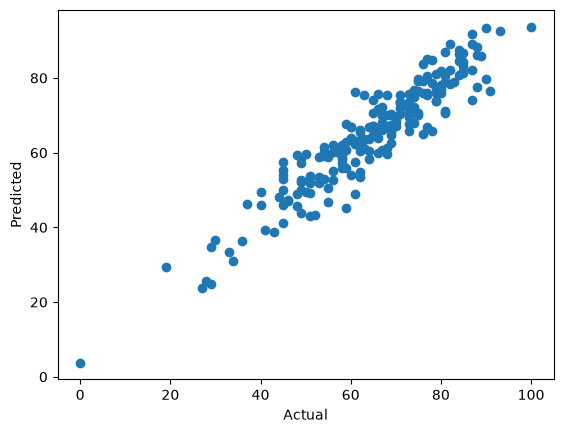

In [49]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

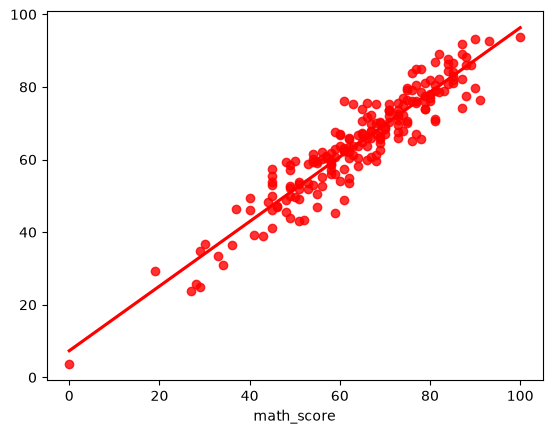

In [50]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='red')

In [51]:
pred_df= pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
